# Lab: Hồi quy Tuyến tính (Linear Regression)

## 1. Bài toán hồi quy là gì?

Khác với **phân loại** (classification) chuyên đoán nhãn rời rạc, **hồi quy** (regression) đoán giá trị *liên tục*: giá nhà, nhiệt độ, doanh thu...

Ví dụ: cho diện tích nhà, đoán giá. Mỗi diện tích cho ra một số thực, không phải nhóm.

## 2. Mô hình tuyến tính

Mô hình đơn giản nhất: giả sử mối quan hệ giữa input $x = (x_1, x_2, \dots, x_n)$ và output $y$ là **tuyến tính**:
$$
\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = w^T x + b
$$

Mục tiêu: tìm $w$ và $b$ sao cho $\hat{y}$ gần $y$ thực tế nhất.

## 3. Hàm mất mát: Mean Squared Error

$$
L(w, b) = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2 = \frac{1}{N}\sum_{i=1}^{N}(w^T x_i + b - y_i)^2
$$

MSE phạt bình phương sai số, nên outlier ảnh hưởng rất mạnh. Nếu data có nhiều outlier, dùng **MAE** (Mean Absolute Error) hoặc **Huber loss** thay thế.

## 4. Hai cách tìm $(w, b)$

### 4.1. Normal Equation: công thức đóng (closed-form)

Đặt $X$ là ma trận $N \times (n+1)$ (thêm cột 1 cho bias), $y$ là vector $N \times 1$. Giải $\nabla L = 0$ cho ra:
$$
\hat{\theta} = (X^T X)^{-1} X^T y
$$

Gọn, không cần lặp. Nhược điểm: tốn $O(n^3)$ để nghịch đảo ma trận, nên chậm khi nhiều feature.

### 4.2. Gradient Descent: cách lặp

Gradient của MSE:
$$\frac{\partial L}{\partial w_j} = \frac{2}{N}\sum_{i=1}^{N}(w^T x_i + b - y_i) \cdot x_{i,j}$$

Cập nhật:
$$w \leftarrow w - \alpha \nabla_w L, \quad b \leftarrow b - \alpha \frac{\partial L}{\partial b}$$

Chậm hơn về toán nhưng scale được lên dataset rất lớn. Đây là cách *neural network* học.

## 5. Đánh giá: $R^2$ và RMSE

**RMSE** (Root MSE): $\sqrt{L}$, có đơn vị đúng bằng đơn vị của $y$, nên dễ diễn giải.

**$R^2$ (coefficient of determination)**: tỷ lệ variance của $y$ được model giải thích.
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$
$R^2 = 1$: hoàn hảo. $R^2 = 0$: bằng đoán mean. $R^2 < 0$: tệ hơn đoán mean.

---

## 0. Trước hết: hồi quy khác phân loại chỗ nào?

![Hồi quy so với phân loại](images/01_hoiquy_vs_phanloai.png)

*Bên trái là hồi quy: model trả về **một con số** trên trục liên tục. Bên phải là phân loại: model trả về **một nhãn** trong tập hữu hạn. Cùng là học có giám sát, nhưng hàm mất mát và cách đánh giá hoàn toàn khác nhau.*

| | Hồi quy | Phân loại |
|---|---|---|
| Output | Số thực $y \in \mathbb{R}$ | Nhãn $y \in \{1,\dots,C\}$ |
| Loss điển hình | MSE, MAE, Huber | Cross-Entropy, Hinge |
| Đánh giá | RMSE, MAE, $R^2$ | Accuracy, F1, AUC |
| Câu hỏi mẫu | "Căn nhà này giá bao nhiêu?" | "Email này có phải spam không?" |

Một trường hợp dễ nhầm: biến mục tiêu có vẻ là số nhưng thực chất là hạng (rating 1 đến 5 sao, xếp loại A/B/C). Với dữ liệu như vậy, hồi quy tuyến tính "chạy được" nhưng giả định *khoảng cách giữa 4 và 5 sao bằng khoảng cách giữa 1 và 2 sao*, và giả định đó thường sai. Khi đó nên dùng ordinal regression hoặc phân loại.

## 3b. Vì sao lại bình phương sai số, và khi nào không nên

![Ý nghĩa hình học của MSE](images/02_mse_hinh_vuong_sai_so.png)

*Mỗi sai số $e_i = \hat{y}_i - y_i$ được biến thành một hình vuông cạnh $|e_i|$. MSE chính là **diện tích trung bình** của các hình vuông đó. Điểm cách đường 2 đơn vị đóng góp diện tích 4; điểm cách 4 đơn vị đóng góp 16, tức gấp 4 lần, dù chỉ xa gấp đôi.*

Ba lý do khiến MSE được chọn làm mặc định:

1. **Khả vi ở mọi nơi.** $|e|$ không có đạo hàm tại $e=0$, còn $e^2$ thì trơn, nên Gradient Descent chạy ổn định.
2. **Có nghiệm đóng.** Đạo hàm của tổng bình phương là tuyến tính theo tham số, nên giải $\nabla L = 0$ ra công thức Normal Equation. Với MAE thì không có may mắn đó.
3. **Có nền tảng thống kê.** Nếu nhiễu $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ độc lập, thì **tối thiểu MSE tương đương ước lượng hợp lý cực đại (MLE)**. Chứng minh ngắn:
$$
\log \mathcal{L}(\theta) = \sum_{i=1}^{N} \log \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(y_i - \theta^Tx_i)^2}{2\sigma^2}}
= \underbrace{-\frac{N}{2}\log(2\pi\sigma^2)}_{\text{hằng số}} - \frac{1}{2\sigma^2}\sum_{i=1}^{N}(y_i - \theta^Tx_i)^2
$$
Cực đại log-likelihood $\iff$ cực tiểu $\sum (y_i - \theta^Tx_i)^2$. Vậy MSE không phải chọn tuỳ tiện: nó là hệ quả của giả định nhiễu Gaussian.

### Mặt trái: MSE rất nhạy với outlier

![MSE, MAE và Huber trước outlier](images/09_outlier_mse_vs_huber.png)

*Chỉ 3 điểm outlier ở $y \approx 72$ đã kéo hệ số OLS lệch hẳn khỏi giá trị thật $w=3$, trong khi `HuberRegressor` gần như không nhúc nhích. Panel phải cho thấy vì sao: MSE (đỏ) tăng theo bậc hai, còn Huber (xanh lá) chuyển sang tuyến tính khi $|e| > \delta$.*

$$
L_\delta(e) = \begin{cases}
\tfrac{1}{2}e^2 & \text{nếu } |e| \le \delta \quad \text{(mượt như MSE ở vùng gần)}\\[4pt]
\delta\left(|e| - \tfrac{1}{2}\delta\right) & \text{nếu } |e| > \delta \quad \text{(chỉ tuyến tính ở vùng xa)}
\end{cases}
$$

| Loss | Nhạy outlier | Khả vi | Ước lượng cái gì | Dùng khi |
|---|---|---|---|---|
| MSE | Rất cao | Mọi nơi | Trung bình có điều kiện $E[y \mid x]$ | Nhiễu Gaussian, ít outlier |
| MAE | Thấp | Trừ $e=0$ | Trung vị có điều kiện | Nhiều outlier, phân phối lệch |
| Huber | Thấp | Mọi nơi | Lai giữa hai cái trên | Mặc định an toàn khi nghi có outlier |
| Quantile (pinball) | Thấp | Trừ $e=0$ | Phân vị $\tau$ bất kỳ | Cần khoảng dự đoán, không chỉ điểm |

Trong thực hành, nên vẽ boxplot hoặc histogram của $y$ trước khi chọn loss. Nếu thấy đuôi dài, hãy thử `HuberRegressor` hoặc `RANSACRegressor` song song với `LinearRegression`.

## 4.1b. Suy ra Normal Equation và ý nghĩa hình học của nó

Viết loss dưới dạng ma trận (bỏ hệ số $1/N$ vì không đổi vị trí cực tiểu):
$$
L(\theta) = \|X\theta - y\|^2 = (X\theta - y)^T(X\theta - y) = \theta^T X^T X \theta - 2\theta^T X^T y + y^Ty
$$

Lấy gradient theo $\theta$ rồi cho bằng $0$:
$$
\nabla_\theta L = 2X^TX\theta - 2X^Ty = 0 \;\Longrightarrow\; \boxed{X^TX\hat{\theta} = X^Ty} \;\Longrightarrow\; \hat{\theta} = (X^TX)^{-1}X^Ty
$$

Phương trình $X^TX\theta = X^Ty$ được gọi là **normal equation** vì nó nói đúng một điều: $X^T(y - X\theta) = 0$, tức **vector phần dư vuông góc (normal) với mọi cột của $X$**.

![Ý nghĩa hình học của Normal Equation](images/05_normal_equation_hinh_chieu.png)

*Không gian cột của $X$ là mặt phẳng chứa mọi dự đoán khả dĩ $X\theta$. Vector $y$ nói chung không nằm trên mặt phẳng đó. Điểm gần $y$ nhất trên mặt phẳng chính là **hình chiếu vuông góc** của $y$, và đó chính là $\hat{y}$. Phần dư $e = y - \hat{y}$ vuông góc với mặt phẳng: đó là toàn bộ nội dung của Normal Equation.*

Ma trận $H = X(X^TX)^{-1}X^T$ thực hiện phép chiếu này ($\hat{y} = Hy$) nên được gọi là **hat matrix**.

### Khi nào Normal Equation gặp rắc rối?

$(X^TX)^{-1}$ chỉ tồn tại khi $X$ **đủ hạng cột** (các cột độc lập tuyến tính). Ba tình huống hỏng:

| Tình huống | Triệu chứng | Cách chữa |
|---|---|---|
| Số feature > số mẫu ($n > N$) | $X^TX$ suy biến, vô số nghiệm | Ridge, hoặc giảm chiều (PCA) |
| Hai feature trùng nhau / cộng tuyến hoàn hảo (ví dụ one-hot đủ $C$ cột + cột bias) | Suy biến | Bỏ 1 cột (`drop_first=True`) |
| Cộng tuyến gần hoàn hảo (multicollinearity) | Nghịch đảo được nhưng hệ số khổng lồ, đổi dấu thất thường | Ridge, hoặc bỏ bớt feature theo VIF |

Thực tế sklearn không gọi `np.linalg.inv`: nó dùng phân rã SVD / `lstsq`, vừa ổn định số học hơn vừa trả về nghiệm chuẩn nhỏ nhất (pseudo-inverse Moore-Penrose) khi ma trận suy biến. Trong lab ta viết `inv` cho dễ hiểu, nhưng code sản phẩm nên dùng `np.linalg.lstsq(X, y, rcond=None)`.

### Normal Equation hay Gradient Descent?

| | Normal Equation | Gradient Descent |
|---|---|---|
| Số vòng lặp | 0 (một phát ra ngay) | Hàng trăm tới hàng triệu |
| Chi phí | $O(n^3 + n^2N)$, rất chậm khi $n$ lớn | $O(nN)$ mỗi vòng |
| Cần chọn learning rate? | Không | Có (và rất nhạy) |
| Cần scale feature? | Không bắt buộc | Cần (xem mục dưới) |
| Ngưỡng thực dụng | $n \lesssim 10^4$ feature | $n$ bất kỳ, $N$ rất lớn |
| Dữ liệu chảy (streaming) | Không | Được (SGD online) |

Một mốc để nhớ: dưới khoảng 10.000 feature thì dùng công thức đóng, trên đó dùng gradient. Toàn bộ deep learning nằm ở cột bên phải.

## 4.2b. Nhìn thấy Gradient Descent đang làm gì

![Mặt mất mát và đường đi của Gradient Descent](images/03_mat_mat_mat_va_duong_di_gd.png)

*Bên trái: MSE vẽ theo hai tham số $(w, b)$ tạo thành một cái **bát lồi** (paraboloid). Bên phải: nhìn từ trên xuống. Mỗi bước GD đi ngược hướng gradient, tức vuông góc với đường đồng mức tại điểm đó. Chú ý hai màu của đường đi: 50 bước đầu (đỏ) đi rất nhanh vào đáy khe, rồi 1450 bước sau (xanh) đi chậm dọc theo khe mới tới được nghiệm tối ưu.*

Vì sao lại chậm như vậy? Vì trong hình này feature $x$ chưa được chuẩn hoá (nằm trong khoảng 0 đến 10), khiến Hessian có **số điều kiện** $\kappa = \lambda_{\max}/\lambda_{\min} \approx 137$. Contour vì thế dẹt như một cái khe hẹp, và số bước GD cần tỷ lệ thuận với $\kappa$. Chỉ cần `StandardScaler` là $\kappa$ về gần 1 và bài toán này chỉ còn tốn vài chục bước. Chi tiết ở mục 4.2c.

Về mặt lý thuyết, hàm mất mát MSE của hồi quy tuyến tính là **lồi** (convex), vì ma trận Hessian $\nabla^2 L = \frac{2}{N}X^TX$ luôn nửa xác định dương. Hệ quả:

- Chỉ có một cực tiểu, không có local minimum để bị kẹt.
- Chọn learning rate đủ nhỏ thì GD chắc chắn hội tụ về nghiệm tối ưu toàn cục.

Đây là điều mà mạng neural không có: loss của MLP là non-convex, đầy local minima và saddle point. Nhưng vì hồi quy tuyến tính lồi, nó là bài toán hoàn hảo để học GD.

### Ba biến thể Gradient Descent

| Biến thể | Mỗi bước dùng | Ưu | Nhược |
|---|---|---|---|
| **Batch GD** | Toàn bộ $N$ mẫu | Gradient chính xác, đường đi mượt | Chậm khi $N$ lớn; không chạy được nếu data không vừa RAM |
| **Stochastic GD (SGD)** | 1 mẫu | Rất nhanh mỗi bước, thoát được vùng phẳng | Đường đi nhiễu, dao động quanh nghiệm |
| **Mini-batch GD** | $B$ mẫu (32 đến 512) | Cân bằng tốt nhất; tận dụng vector hoá GPU | Thêm một hyperparameter $B$ |

Trong thực tế mini-batch được dùng gần như khắp nơi: mọi framework deep learning đều mặc định dùng nó. Nhiễu của SGD/mini-batch không hẳn xấu: nó đóng vai trò như một dạng regularization nhẹ và giúp thoát saddle point.

Trong sklearn: `SGDRegressor(loss='squared_error')` là bản GD của `LinearRegression`, dùng khi dữ liệu quá lớn cho công thức đóng.

### Xem Gradient Descent chạy từng bước

![Gradient Descent học dần đường hồi quy](images/anim_gradient_descent.gif)

*Bên trái là đường hồi quy đang được học, bên phải là vị trí của cặp $(w, b)$ trên mặt mất mát. Hãy chú ý hai điều: những bước đầu tiên đi rất dài vì gradient còn lớn, và càng gần đáy thì bước càng ngắn lại dù learning rate không hề thay đổi.*

## 4.2c. Learning rate: tham số dễ làm hỏng việc nhất

![Ảnh hưởng của learning rate](images/04_anh_huong_learning_rate.png)

*Cùng một bài toán, cùng điểm khởi tạo, chỉ đổi $\alpha$. Quá nhỏ (0.02): đi đúng hướng nhưng 40 bước vẫn chưa tới đích, MSE mới xuống 23.6. Vừa (0.35): cắm thẳng vào tâm sau khoảng 15 bước, MSE = 1.36. Quá lớn (1.02): mỗi bước vọt qua đáy sang sườn bên kia rồi văng ra xa dần, MSE tăng lên 11 460 và sẽ thành `inf`. Chú ý hàng dưới: đường loss của panel thứ ba đi lên, không phải đi xuống.*

Vì hình này dùng feature đã chuẩn hoá nên Hessian đúng bằng $2I$, tức $\lambda_{\max}=2$ và ngưỡng phân kỳ đúng bằng $2/\lambda_{\max} = 1.0$. Đó là lý do $\alpha = 0.35$ vẫn an toàn còn $\alpha = 1.02$ thì hỏng: không phải chuyện may rủi, mà là một con số tính được trước.

Có một ngưỡng lý thuyết rõ ràng: GD trên hàm bậc hai hội tụ khi
$$
0 < \alpha < \frac{2}{\lambda_{\max}}
$$
với $\lambda_{\max}$ là trị riêng lớn nhất của Hessian $\frac{2}{N}X^TX$. Vượt ngưỡng này thì chắc chắn phân kỳ, không có ngoại lệ.

Cách chẩn đoán khi train:

| Triệu chứng đường loss | Chẩn đoán | Xử lý |
|---|---|---|
| Giảm rất chậm, gần như thẳng | $\alpha$ quá nhỏ | Nhân $\alpha$ lên 3 đến 10 lần |
| Giảm nhanh rồi phẳng ngang | Đã hội tụ (hoặc kẹt) | Dừng lại, hoặc giảm $\alpha$ để tinh chỉnh |
| Dao động lên xuống quanh một mức | $\alpha$ hơi lớn | Giảm $\alpha$, hoặc dùng learning-rate decay |
| Tăng vọt, ra `nan` / `inf` | $\alpha$ quá lớn | Giảm $\alpha$ 10 lần và scale feature |

Chiến lược thực dụng: thử $\alpha \in \{10^{-1}, 10^{-2}, 10^{-3}, 10^{-4}\}$, chọn giá trị lớn nhất mà loss vẫn giảm ổn định, rồi thêm **learning rate decay** (giảm dần $\alpha$ theo thời gian) để tinh chỉnh ở cuối.

### Vì sao Gradient Descent cần scale feature

Nhìn lại đường đi GD ở hình mục 4.2b: nó không cắm thẳng vào tâm mà đi vào khe rồi đi rất chậm dọc theo khe. Nguyên nhân: contour là hình **ellipse dẹt**, không phải hình tròn.

Khi các feature có thang đo lệch nhau (ví dụ `Age` ∈ [20, 70] và `Income` ∈ [20.000, 200.000]), Hessian $X^TX$ có **số điều kiện** (condition number) $\kappa = \lambda_{\max}/\lambda_{\min}$ rất lớn; contour vì thế dẹt như quả trứng, và gradient hầu như luôn trỏ ngang qua khe hẹp thay vì dọc theo khe. Số bước cần để hội tụ tỷ lệ với $\kappa$.

`StandardScaler` kéo mọi feature về cùng thang $\mu=0, \sigma=1$, contour tròn lại và GD đi gần như thẳng vào tâm. Vì vậy scale không phải mẹo trang trí mà là điều kiện cần để GD chạy nhanh.

Lưu ý rằng Normal Equation không cần scale (kết quả toán học y hệt), còn Gradient Descent và mọi mô hình có regularization thì cần.

## 5b. Bốn giả định của hồi quy tuyến tính và cách kiểm tra bằng mắt

Hồi quy tuyến tính chỉ cho kết quả *đáng tin* khi bốn giả định sau tạm ổn (viết tắt tiếng Anh là **LINE**):

| Giả định | Nội dung | Vi phạm thì sao | Kiểm tra bằng |
|---|---|---|---|
| **L**inearity | Quan hệ giữa $x$ và $E[y]$ là tuyến tính | Model chệch có hệ thống | Residual plot có dạng cong |
| **I**ndependence | Các phần dư độc lập nhau | Sai số chuẩn bị đánh giá thấp, p-value sai | Durbin-Watson (dữ liệu chuỗi thời gian) |
| **N**ormality | Phần dư phân phối chuẩn | Khoảng tin cậy / kiểm định không còn đúng | Q-Q plot, histogram phần dư |
| **E**qual variance | Phương sai phần dư không đổi (homoscedasticity) | Ước lượng vẫn không chệch nhưng kém hiệu quả | Residual plot hình phễu |

Lưu ý rằng giả định Normality chỉ cần cho suy diễn thống kê (khoảng tin cậy, p-value). Nếu chỉ quan tâm dự đoán, vi phạm nó không nghiêm trọng. Còn Linearity và Equal variance thì ảnh hưởng trực tiếp đến chất lượng dự đoán.

![Ba dạng residual plot điển hình](images/06_chan_doan_phan_du.png)

*Cách đọc: vẽ phần dư theo giá trị dự đoán. Trái: mây điểm ngẫu nhiên quanh đường 0, không có hình thù, mô hình ổn. Giữa: hình chữ U rõ ràng, còn quan hệ phi tuyến chưa được model bắt, hãy thêm $x^2$ hoặc đổi sang model phi tuyến. Phải: hình cái phễu loe ra, phương sai tăng theo $\hat{y}$, hãy thử biến đổi $\log(y)$ hoặc dùng Weighted Least Squares.*

Nguyên tắc đầu tiên khi làm hồi quy là vẽ residual plot trước khi báo cáo $R^2$. Một $R^2 = 0.9$ đi kèm residual plot hình chữ U vẫn là một mô hình sai: nó chỉ đang sai *một cách có hệ thống* mà bạn chưa nhìn thấy.

## 5c. Đọc $R^2$ cho đúng

$R^2$ có một tính chất cần lưu ý: thêm feature bất kỳ, kể cả feature ngẫu nhiên vô nghĩa, $R^2$ trên tập train không bao giờ giảm. Vì vậy dùng $R^2$ để so sánh các model có số feature khác nhau là sai lầm.

**Adjusted $R^2$** vá lỗ hổng đó bằng cách phạt số feature:
$$
R^2_{\text{adj}} = 1 - (1 - R^2)\frac{N - 1}{N - n - 1}
$$
với $N$ = số mẫu, $n$ = số feature. Thêm feature vô dụng thì $R^2$ tăng rất ít nhưng mẫu số co lại, nên $R^2_{\text{adj}}$ giảm. Đó là tín hiệu "feature này không đáng giá".

| Chỉ số | Đơn vị | Đọc thế nào | Cẩn thận |
|---|---|---|---|
| **MSE** | (đơn vị $y$)² | Càng nhỏ càng tốt | Khó diễn giải vì bình phương |
| **RMSE** | Đơn vị $y$ | "Sai trung bình khoảng ± RMSE" | Vẫn nhạy outlier |
| **MAE** | Đơn vị $y$ | Sai số tuyệt đối trung bình | Không phạt nặng lỗi lớn |
| **$R^2$** | Không đơn vị | Tỷ lệ phương sai giải thích được | Luôn tăng khi thêm feature |
| **$R^2_{\text{adj}}$** | Không đơn vị | Như trên nhưng đã phạt số feature | Chỉ dùng cho tuyến tính |
| **MAPE** | % | Sai số phần trăm, dễ báo cáo | Không dùng được khi $y$ gần 0 |

Ba mốc cần nhớ: $R^2 = 1$ hoàn hảo; $R^2 = 0$ đúng bằng việc luôn đoán $\bar{y}$; $R^2 < 0$ tệ hơn cả đoán trung bình (rất hay gặp trên tập test khi model overfit).

# THỰC HÀNH 1: Hồi quy 1 biến với dữ liệu giả lập

Sinh dữ liệu $y = 3x + 5 + \varepsilon$, train cả 3 cách (Normal Equation, GD thủ công, sklearn) và so sánh.

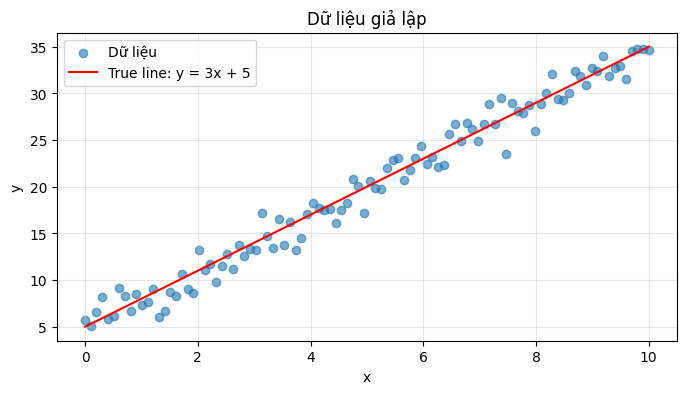

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)

# Sinh data y = 3x + 5 + nhiễu
N = 100
x = np.linspace(0, 10, N)
y = 3 * x + 5 + np.random.randn(N) * 1.5    # nhiễu N(0, 1.5)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.6, label='Dữ liệu')
plt.plot(x, 3*x + 5, 'r-', label='True line: y = 3x + 5')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu giả lập')
plt.show()

### Cách 1: Normal Equation

In [2]:
# Thêm cột 1 cho bias: X có shape (N, 2), cột đầu là 1, cột sau là x.
X = np.column_stack([np.ones(N), x])
theta_ne = np.linalg.inv(X.T @ X) @ X.T @ y
b_ne, w_ne = theta_ne
print(f'Normal Equation: w = {w_ne:.4f},  b = {b_ne:.4f}')
print(f'                 (giá trị thật: w=3, b=5)')

Normal Equation: w = 3.0207,  b = 4.7408
                 (giá trị thật: w=3, b=5)


### Cách 2: Gradient Descent thủ công

Gradient Descent: w = 3.0250,  b = 4.7119
Final loss: 1.8338


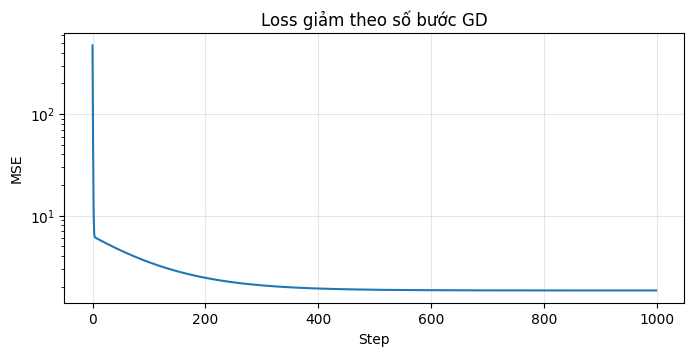

In [3]:
w, b = 0.0, 0.0
lr = 0.01
loss_history = []

for step in range(1000):
    y_hat = w * x + b
    err = y_hat - y
    loss = (err ** 2).mean()
    loss_history.append(loss)

    # gradient
    dw = 2 * (err * x).mean()
    db = 2 * err.mean()
    w -= lr * dw
    b -= lr * db

print(f'Gradient Descent: w = {w:.4f},  b = {b:.4f}')
print(f'Final loss: {loss:.4f}')

plt.figure(figsize=(8, 3.5))
plt.plot(loss_history); plt.xlabel('Step'); plt.ylabel('MSE'); plt.yscale('log')
plt.title('Loss giảm theo số bước GD'); plt.grid(alpha=0.3); plt.show()

### Cách 3: sklearn

sklearn:         w = 3.0207,  b = 4.7408


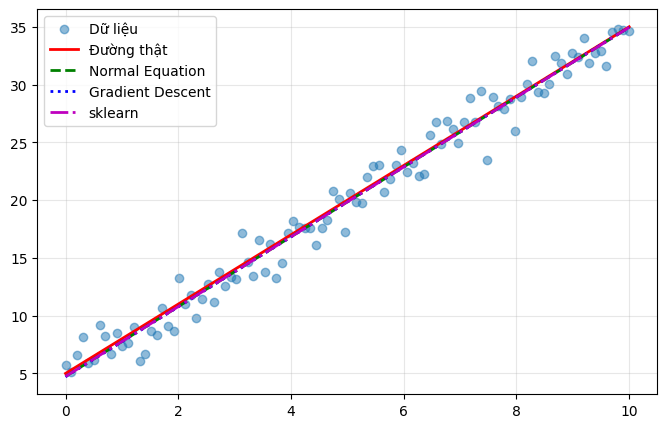

In [4]:
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
print(f'sklearn:         w = {model.coef_[0]:.4f},  b = {model.intercept_:.4f}')

# Vẽ ba đường
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label='Dữ liệu')
plt.plot(x, 3*x + 5, 'r-', linewidth=2, label='Đường thật')
plt.plot(x, w_ne*x + b_ne, 'g--', linewidth=2, label='Normal Equation')
plt.plot(x, w*x + b, 'b:', linewidth=2, label='Gradient Descent')
plt.plot(x, model.coef_[0]*x + model.intercept_, 'm-.', linewidth=2, label='sklearn')
plt.legend(); plt.grid(alpha=0.3); plt.show()

Ba cách cho ra gần như cùng một cặp $(w, b)$; Gradient Descent chỉ lệch rất nhỏ nếu số vòng lặp chưa đủ.

# THỰC HÀNH 2: Hồi quy đa biến với California Housing

In [5]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X, y = housing.data, housing.target
feat_names = housing.feature_names
print(f'Shape: X={X.shape}, y={y.shape}')
print(f'Features: {feat_names}')
print(f'Target = giá nhà (đơn vị: trăm nghìn USD)')

Shape: X=(20640, 8), y=(20640,)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target = giá nhà (đơn vị: trăm nghìn USD)


Test RMSE: 0.746  (đơn vị $100K)
Test MAE : 0.533
Test R^2 : 0.576


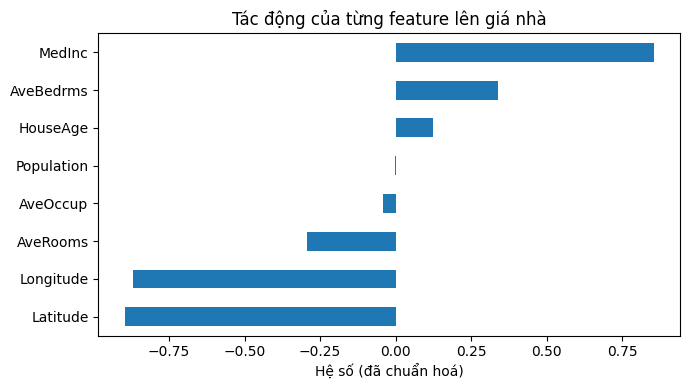

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaling: fit chỉ trên train để tránh data leakage.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f'Test RMSE: {rmse:.3f}  (đơn vị $100K)')
print(f'Test MAE : {mae:.3f}')
print(f'Test R^2 : {r2:.3f}')

# Hệ số
coef = pd.Series(model.coef_, index=feat_names).sort_values()
coef.plot.barh(figsize=(7, 4)); plt.xlabel('Hệ số (đã chuẩn hoá)')
plt.title('Tác động của từng feature lên giá nhà'); plt.tight_layout(); plt.show()

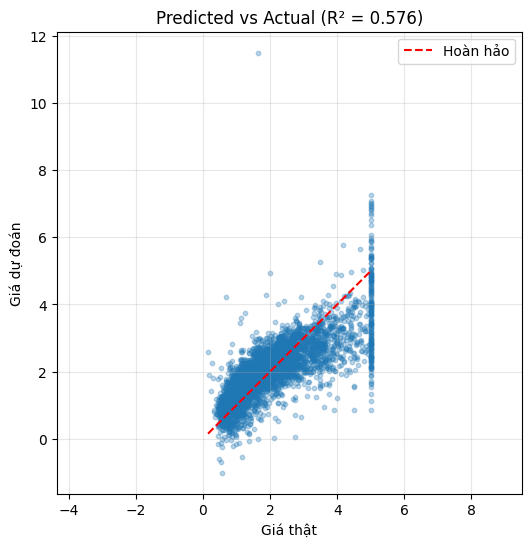

In [7]:
# Vẽ predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Hoàn hảo')
plt.xlabel('Giá thật'); plt.ylabel('Giá dự đoán')
plt.title(f'Predicted vs Actual (R² = {r2:.3f})')
plt.legend(); plt.grid(alpha=0.3)
plt.axis('equal'); plt.show()

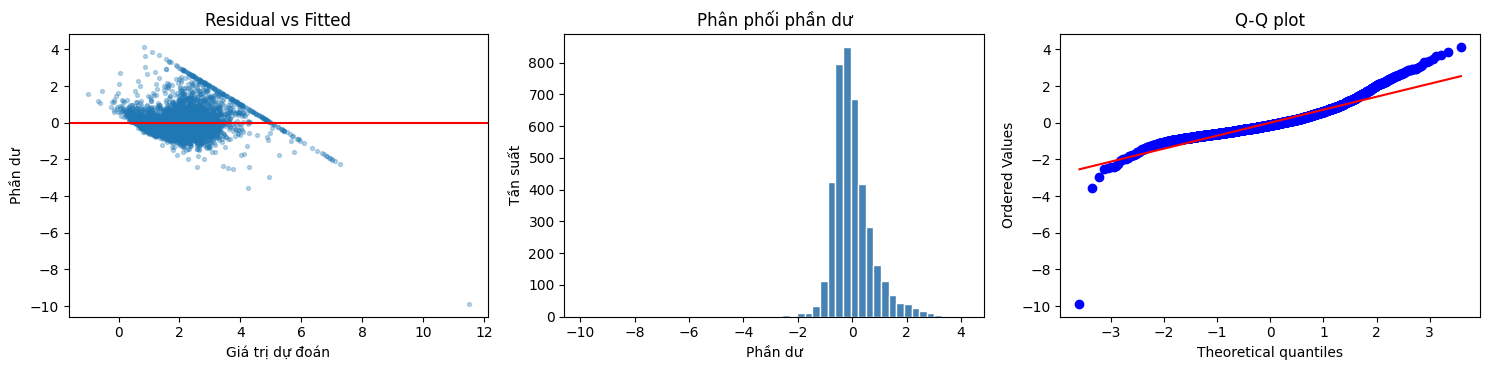

R^2          = 0.5758
Adjusted R^2 = 0.5750   (8 feature, 4128 mẫu test)


In [8]:
# Kiểm tra giả định của model California Housing vừa train ở trên;
# bước này cho biết nhiều điều mà con số R^2 không cho thấy.
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# (1) Residual vs Fitted: kiểm tra linearity + homoscedasticity
axes[0].scatter(y_pred, residuals, s=8, alpha=0.3)
axes[0].axhline(0, color='red', lw=1.5)
axes[0].set_xlabel('Giá trị dự đoán'); axes[0].set_ylabel('Phần dư')
axes[0].set_title('Residual vs Fitted')

# (2) Histogram phần dư: kiểm tra normality
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Phần dư'); axes[1].set_ylabel('Tần suất')
axes[1].set_title('Phân phối phần dư')

# (3) Q-Q plot: normality chặt chẽ hơn histogram
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot')

plt.tight_layout(); plt.show()

# Adjusted R^2
n_samples, n_features = X_test_s.shape
r2_adj = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
print(f'R^2          = {r2:.4f}')
print(f'Adjusted R^2 = {r2_adj:.4f}   ({n_features} feature, {n_samples} mẫu test)')

Nhận xét: phần dư có xu hướng cụp xuống ở vùng giá cao, vì target của California Housing bị cắt ngọn ở mức 5.0 (tức 500 nghìn USD). Model không thể đoán quá 5 nên phần dư ở vùng đó lệch hẳn về một phía. Đây là ví dụ điển hình cho việc residual plot phát hiện vấn đề mà $R^2$ không cho thấy.

## 6. Regularization: Ridge và Lasso

Hồi quy thường gặp vấn đề khi feature có tương quan cao (multicollinearity), khi đó hệ số trở nên rất lớn và không ổn định. **Regularization** thêm penalty vào loss để khống chế:

**Ridge (L2)**: $L = \text{MSE} + \alpha \sum w_j^2$. Co hệ số về 0 nhưng không chính xác là 0.

**Lasso (L1)**: $L = \text{MSE} + \alpha \sum |w_j|$. Có thể đẩy hệ số về *đúng 0*, tức là tự động chọn feature.

### Hình học đằng sau Ridge và Lasso: vì sao chỉ Lasso mới đẩy được hệ số về 0?

![Ridge so với Lasso](images/08_ridge_vs_lasso.png)

*Cách đọc hai panel trái: các ellipse đỏ là đường đồng mức của MSE (tâm = nghiệm OLS không bị phạt). Vùng xanh là **miền khả thi** do regularization áp đặt. Nghiệm bị phạt là điểm mà ellipse chạm vùng xanh lần đầu.*

- **Ridge (L2)** có miền khả thi là hình tròn, trơn, không góc cạnh. Ellipse hầu như luôn chạm vào một điểm có cả hai toạ độ khác 0, nên hệ số bị co nhỏ nhưng không bao giờ đúng bằng 0.
- **Lasso (L1)** có miền khả thi là hình thoi với góc nhọn nằm ngay trên trục toạ độ. Ellipse rất dễ chạm đúng vào góc, nghiệm rơi vào trục và hệ số đó bằng đúng 0.

Panel phải minh hoạ hệ quả: khi tăng $\alpha$, các hệ số của Lasso lần lượt "rụng" về 0, và đó chính là **chọn feature tự động** (embedded feature selection).

| | Ridge (L2) | Lasso (L1) | ElasticNet |
|---|---|---|---|
| Penalty | $\alpha\sum w_j^2$ | $\alpha\sum \lvert w_j \rvert$ | Kết hợp cả hai |
| Hệ số về đúng 0? | Không | Có | Có |
| Feature tương quan cao | Chia đều trọng số cho cả nhóm | Chọn một cái khá tuỳ ý, bỏ phần còn lại | Giữ cả nhóm (grouping effect) |
| $n > N$ (nhiều feature hơn mẫu) | Vẫn chạy | Chọn tối đa $N$ feature | Không giới hạn đó |
| Nghiệm đóng | Có: $(X^TX + \alpha I)^{-1}X^Ty$ | Không (phải dùng coordinate descent) | Không |
| Khi nào dùng | Mọi feature đều có ích chút ít | Tin rằng phần lớn feature là vô dụng | Nhiều feature và chúng tương quan nhau |

Một cách nhìn khác (Bayes): Ridge = đặt **prior Gaussian** lên hệ số, Lasso = đặt **prior Laplace** (nhọn tại 0 nên "kéo" hệ số về 0). Nghiệm chính là ước lượng MAP.

Ridge còn có một tác dụng phụ hữu ích: $(X^TX + \alpha I)$ luôn khả nghịch kể cả khi $X^TX$ suy biến, nên Ridge cứu được trường hợp multicollinearity hoàn hảo mà OLS chịu thua.

> **Lưu ý:** cần scale trước khi regularize. Penalty cộng trực tiếp độ lớn hệ số. Feature đo bằng mét và feature đo bằng milimét sẽ bị phạt hoàn toàn khác nhau dù mang cùng thông tin. Luôn dùng `make_pipeline(StandardScaler(), Ridge(alpha=...))`.

In [9]:
for name, mdl in [('Linear', LinearRegression()),
                  ('Ridge α=1', Ridge(alpha=1.0)),
                  ('Ridge α=10', Ridge(alpha=10.0)),
                  ('Lasso α=0.1', Lasso(alpha=0.1)),
                  ('Lasso α=1', Lasso(alpha=1.0))]:
    mdl.fit(X_train_s, y_train)
    pred = mdl.predict(X_test_s)
    r2 = r2_score(y_test, pred)
    nz = np.sum(np.abs(mdl.coef_) > 1e-6)
    print(f'{name:15s}  R² = {r2:.4f}  | Số coef khác 0: {nz}/{len(mdl.coef_)}')

Linear           R² = 0.5758  | Số coef khác 0: 8/8
Ridge α=1        R² = 0.5758  | Số coef khác 0: 8/8
Ridge α=10       R² = 0.5761  | Số coef khác 0: 8/8
Lasso α=0.1      R² = 0.4814  | Số coef khác 0: 3/8
Lasso α=1        R² = -0.0002  | Số coef khác 0: 0/8


## 7. Polynomial regression: học quan hệ phi tuyến

Linear Regression không *bắt buộc* dữ liệu phải tuyến tính theo $x$. Ta có thể tạo feature mới $x^2, x^3$ rồi chạy linear regression: đây chính là **polynomial regression**.

### Bias-Variance: khung tư duy đằng sau mọi lựa chọn độ phức tạp

![Bias-variance trade-off](images/07_bias_variance_tradeoff.png)

*Ba panel trái: cùng 18 điểm train, chỉ đổi bậc đa thức. Degree 1 quá cứng, bỏ sót hẳn hình dạng sin, **bias cao**. Degree 6 bám gần như trùng hàm thật. Degree 17 uốn éo bám theo từng hạt nhiễu và vọt lên ở hai mép, **variance cao**. Panel phải: train RMSE đi xuống rồi nằm phẳng, còn test RMSE tạo hình chữ U, đáy chữ U ở bậc 6 chính là điểm nên dừng.*

Một chi tiết kỹ thuật trong hình này: pipeline là `PolynomialFeatures`, rồi `StandardScaler`, rồi `LinearRegression`. Nếu bỏ `StandardScaler`, ma trận thiết kế (dạng Vandermonde) bị suy biến số học ở bậc cao và train RMSE lại tăng ở bậc lớn. Đó là hiện tượng số học, không phải hiện tượng thống kê, nhưng rất dễ khiến người đọc kết luận nhầm.

Sai số kỳ vọng của model trên một điểm mới tách được thành ba phần:
$$
\underbrace{E\big[(y - \hat{f}(x))^2\big]}_{\text{sai số kỳ vọng}} = \underbrace{\big(E[\hat{f}(x)] - f(x)\big)^2}_{\text{Bias}^2} + \underbrace{E\big[(\hat{f}(x) - E[\hat{f}(x)])^2\big]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{nhiễu không thể khử}}
$$

- **Bias**: model quá đơn giản, sai một cách có hệ thống dù cho bao nhiêu dữ liệu cũng vậy.
- **Variance**: model quá linh hoạt, đổi tập train một chút là kết quả đổi hẳn.
- **$\sigma^2$**: nhiễu bản chất của dữ liệu, không mô hình nào vượt qua được. Đây là trần hiệu năng lý thuyết.

| Triệu chứng | Chẩn đoán | Cách chữa |
|---|---|---|
| Train error cao, test error cao (xấp xỉ nhau) | **Underfit** (bias cao) | Thêm feature, tăng bậc/độ sâu, giảm regularization, train lâu hơn |
| Train error thấp, test error cao (khoảng cách lớn) | **Overfit** (variance cao) | Thêm dữ liệu, tăng regularization, giảm độ phức tạp, early stopping |
| Cả hai thấp và sát nhau | Ổn | Dừng lại |
| Train error cao hơn test error | Nghi có bug hoặc rò rỉ dữ liệu | Kiểm tra lại quy trình split/scale |

Ba cách kéo giảm variance mà không tăng bias, sẽ gặp lại suốt môn học: (1) thêm dữ liệu, (2) regularization, (3) ensemble. Đúng ba thứ đó sẽ được dùng lại ở bài Random Forest.

> **Lưu ý:** không dùng tập test để chọn bậc đa thức rồi lại báo cáo kết quả trên chính tập test đó. Làm vậy tập test đã trở thành tập validation, và con số báo cáo là lạc quan giả tạo. Hãy dùng cross-validation trên tập train để chọn, rồi mới chạm vào test đúng một lần.

degree= 1:  train RMSE = 0.4085   test RMSE = 0.5353
degree= 3:  train RMSE = 0.2126   test RMSE = 0.2276
degree=15:  train RMSE = 0.1216   test RMSE = 192.4133


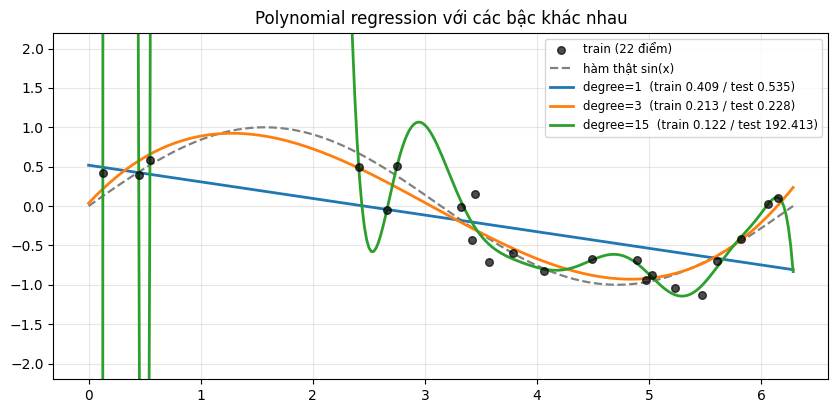

In [10]:
# Sinh data phi tuyến: y = sin(x) + nhiễu.
# cố ý dùng ít điểm (22) để hiện tượng overfit lộ rõ khi tăng bậc
np.random.seed(0)
x_nl = np.sort(np.random.uniform(0, 2*np.pi, 22))
y_nl = np.sin(x_nl) + np.random.randn(22) * 0.20

# tập kiểm tra riêng, sinh từ cùng phân phối, để đo khả năng tổng quát hoá
x_val = np.sort(np.random.uniform(0, 2*np.pi, 300))
y_val = np.sin(x_val) + np.random.randn(300) * 0.20

xx = np.linspace(0, 2*np.pi, 300).reshape(-1, 1)

plt.figure(figsize=(10, 4.5))
plt.scatter(x_nl, y_nl, alpha=0.7, color='k', s=30, zorder=5, label='train (22 điểm)')
plt.plot(xx, np.sin(xx), '--', color='gray', lw=1.6, label='hàm thật sin(x)')

for deg in [1, 3, 15]:
    # cần StandardScaler: không có nó, ma trận Vandermonde bậc cao suy biến số học
    # và train RMSE tăng theo bậc (hiện tượng số học, xem ghi chú ở mục bias-variance)
    mdl = make_pipeline(PolynomialFeatures(deg), StandardScaler(), LinearRegression())
    mdl.fit(x_nl.reshape(-1, 1), y_nl)
    rmse_tr = np.sqrt(mean_squared_error(y_nl, mdl.predict(x_nl.reshape(-1, 1))))
    rmse_te = np.sqrt(mean_squared_error(y_val, mdl.predict(x_val.reshape(-1, 1))))
    plt.plot(xx, mdl.predict(xx), lw=2,
             label=f'degree={deg}  (train {rmse_tr:.3f} / test {rmse_te:.3f})')
    print(f'degree={deg:2d}:  train RMSE = {rmse_tr:.4f}   test RMSE = {rmse_te:.4f}')

plt.ylim(-2.2, 2.2); plt.legend(fontsize=8.5); plt.grid(alpha=0.3)
plt.title('Polynomial regression với các bậc khác nhau')
plt.show()

Nhận xét: degree 1 underfit, đường thẳng không bám được hình sin. Degree 3 cho test RMSE thấp nhất. Degree 15 có train RMSE tiếp tục giảm nhưng test RMSE tăng rõ, và đường vẽ uốn theo từng hạt nhiễu: đó là overfit. Chỉ nhìn train RMSE thì không phát hiện được overfit, vì train RMSE gần như luôn giảm khi tăng bậc; cần có tập test.

## Tổng kết

1. Linear Regression: $\hat{y} = w^T x + b$, tối thiểu MSE.
2. Hai cách giải: Normal Equation (đóng) và Gradient Descent (lặp).
3. Đánh giá: RMSE, MAE, R².
4. **Ridge / Lasso** giúp chống overfitting và (Lasso) chọn feature.
5. **Polynomial regression**: thêm $x^2, x^3, ...$ để học quan hệ phi tuyến, nhưng coi chừng overfit.
6. Cần scale feature trước khi dùng regularization (vì penalty so với độ lớn coef).

# BÀI TẬP VỀ NHÀ

## Bài 1: Cài đặt từ scratch
Viết class `MyLinearRegression` với 2 method:
- `fit(X, y)` dùng Normal Equation.
- `predict(X)` dùng coefficient đã fit.

Test trên California Housing. So sánh hệ số và R² với `sklearn.LinearRegression`. Phải gần như giống hệt.

*Gợi ý:* nhớ thêm cột 1 cho bias trước khi inverse.

## Bài 2: Từ diện tích đoán giá nhà
Sinh dữ liệu giả lập:
- 200 căn nhà.
- Diện tích: từ 30m² đến 200m².
- Giá = 50 + 30·area + nhiễu (đơn vị triệu).

Train Linear Regression. Vẽ scatter + đường hồi quy. Báo cáo RMSE.

## Bài 3: Outlier ảnh hưởng MSE thế nào?
Lấy data `y = 3x + 5 + nhiễu` ở Thực hành 1. Thêm 5 outlier mạnh (y = 100). Train Linear Regression.

Sau đó dùng `HuberRegressor` (`from sklearn.linear_model import HuberRegressor`), vốn robust với outlier. So sánh hệ số học được. Cái nào sát true (3, 5) hơn?

## Bài 4: Ridge vs Lasso khi có feature thừa
Sinh dữ liệu: 100 mẫu, 20 feature, nhưng *chỉ 5 feature thật sự liên quan* đến y (15 còn lại là nhiễu).

1. Train `LinearRegression`, `Ridge(α=1)`, `Lasso(α=0.1)`.
2. Đếm số coef khác 0 sau train.
3. Lasso có "phát hiện" được 5 feature thật không?

*Gợi ý:* dùng `np.abs(model.coef_) > 1e-6` để đếm.

## Bài 5: Polynomial degree và overfit

Dùng lại bộ dữ liệu sin ở phần thực hành cuối (22 điểm train, 300 điểm test):
1. Train polynomial regression với `degree` chạy từ 1 đến 17.
2. Với mỗi degree, đo RMSE trên cả tập train và tập test đã có sẵn.
3. Vẽ hai đường RMSE theo degree, trục y để thang log cho dễ nhìn.
4. Quan sát: train RMSE đi xuống rồi nằm phẳng, test RMSE giảm rồi quay đầu đi lên. Đáy của đường test nằm ở degree nào?

*Gợi ý:* pipeline phải là `make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())`. Nếu bỏ `StandardScaler`, ma trận thiết kế dạng Vandermonde sẽ suy biến số học ở bậc cao và bạn sẽ thấy train RMSE tăng theo bậc, một kết quả vô lý về mặt thống kê. Gặp hiện tượng đó thì đừng vội kết luận, hãy kiểm tra lại pipeline trước.

*Câu hỏi thêm:* vì sao bài này cố ý chỉ dùng 22 điểm train? Thử tăng lên 500 điểm rồi chạy lại. Đường test RMSE còn quay đầu đi lên nữa không? Điều đó nói gì về quan hệ giữa lượng dữ liệu và overfitting?

---
## LỜI GIẢI BÀI TẬP VỀ NHÀ
---
### Lời giải Bài 1: Cài đặt MyLinearRegression từ scratch dùng Normal Equation

In [11]:
# 1. Định nghĩa class MyLinearRegression
class MyLinearRegression:
    def __init__(self):
        self.w = None       # Trọng số cho các features
        self.b = None       # Hệ số chặn (intercept / bias)
        self.theta = None   # Vector [b, w_1, ..., w_n]
        
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        N = X.shape[0]
        # Thêm cột 1 vào đầu ma trận cho hệ số bias b
        X_b = np.column_stack([np.ones(N), X])
        # Công thức nghiệm đóng Normal Equation: theta = (X_b^T X_b)^(-1) X_b^T y
        # Dùng pinv để đảm bảo luôn nghịch đảo ổn định số học
        self.theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        self.b = float(self.theta[0])
        self.w = np.array(self.theta[1:], dtype=np.float64)
        return self
        
    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.w + self.b

# 2. Kiểm thử trên tập dữ liệu California Housing
housing = fetch_california_housing()
X_raw, y_raw = housing.data, housing.target
X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# Fit mô hình tự viết và mô hình sklearn
my_lr = MyLinearRegression().fit(X_tr_s, y_tr)
sk_lr = LinearRegression().fit(X_tr_s, y_tr)

# Dự đoán và tính toán các chỉ số
my_pred = my_lr.predict(X_te_s)
sk_pred = sk_lr.predict(X_te_s)

print(f"[So sánh kết quả trên tập kiểm tra (Test Set)]:")
print(f"MyLinearRegression:   R² = {r2_score(y_te, my_pred):.6f}, RMSE = {np.sqrt(mean_squared_error(y_te, my_pred)):.6f}")
print(f"sklearn.LinearReg:   R² = {r2_score(y_te, sk_pred):.6f}, RMSE = {np.sqrt(mean_squared_error(y_te, sk_pred)):.6f}")
print(f"Chênh lệch R²:        {abs(r2_score(y_te, my_pred) - r2_score(y_te, sk_pred)):.2e}")
print(f"Chênh lệch bias b:    {abs(my_lr.b - sk_lr.intercept_):.2e}")
print(f"Chênh lệch max w:     {np.max(np.abs(my_lr.w - sk_lr.coef_)):.2e}")
print("=> Nhận xét: Kết quả của MyLinearRegression hoàn toàn trùng khớp với sklearn!")

[So sánh kết quả trên tập kiểm tra (Test Set)]:
MyLinearRegression:   R² = 0.575788, RMSE = 0.745581
sklearn.LinearReg:   R² = 0.575788, RMSE = 0.745581
Chênh lệch R²:        1.78e-15
Chênh lệch bias b:    4.44e-16
Chênh lệch max w:     7.55e-15
=> Nhận xét: Kết quả của MyLinearRegression hoàn toàn trùng khớp với sklearn!


---
### Lời giải Bài 2: Từ diện tích đoán giá nhà (Dữ liệu giả lập 200 căn)

Hàm thật gốc:      Giá = 30 * area + 50
Hồi quy học được:  Giá = 29.86 * area + 85.69
Báo cáo chỉ số:
  - RMSE : 289.90 triệu đồng
  - MAE  : 228.84 triệu đồng
  - R²   : 0.9637


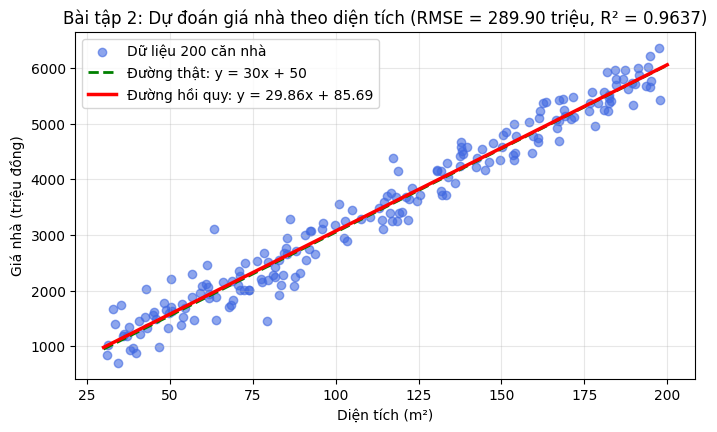

In [12]:
np.random.seed(42)
N_houses = 200
# Diện tích từ 30m2 đến 200m2
area = np.random.uniform(30, 200, N_houses)
# Giá = 50 + 30 * area + nhiễu Gauss N(0, 300^2) (đơn vị: triệu đồng)
noise = np.random.normal(0, 300, N_houses)
price = 50 + 30 * area + noise

# Huấn luyện Linear Regression
lr_house = LinearRegression()
lr_house.fit(area.reshape(-1, 1), price)
price_pred = lr_house.predict(area.reshape(-1, 1))

rmse_house = np.sqrt(mean_squared_error(price, price_pred))
mae_house = mean_absolute_error(price, price_pred)
r2_house = r2_score(price, price_pred)

print(f"Hàm thật gốc:      Giá = 30 * area + 50")
print(f"Hồi quy học được:  Giá = {lr_house.coef_[0]:.2f} * area + {lr_house.intercept_:.2f}")
print(f"Báo cáo chỉ số:")
print(f"  - RMSE : {rmse_house:.2f} triệu đồng")
print(f"  - MAE  : {mae_house:.2f} triệu đồng")
print(f"  - R²   : {r2_house:.4f}")

# Vẽ scatter + đường hồi quy
plt.figure(figsize=(8, 4.5))
x_grid = np.linspace(30, 200, 300).reshape(-1, 1)
plt.scatter(area, price, alpha=0.6, color='royalblue', label='Dữ liệu 200 căn nhà')
plt.plot(x_grid, 50 + 30 * x_grid, 'g--', lw=2, label='Đường thật: y = 30x + 50')
plt.plot(x_grid, lr_house.predict(x_grid), 'r-', lw=2.5, label=f'Đường hồi quy: y = {lr_house.coef_[0]:.2f}x + {lr_house.intercept_:.2f}')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Giá nhà (triệu đồng)')
plt.title(f'Bài tập 2: Dự đoán giá nhà theo diện tích (RMSE = {rmse_house:.2f} triệu, R² = {r2_house:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
### Lời giải Bài 3: Outlier ảnh hưởng MSE thế nào? (OLS vs HuberRegressor)

Ground Truth:      w = 3.0000,  b = 5.0000
Linear Regression: w = 2.4682,  b = 11.6220
HuberRegressor:    w = 3.0136,  b = 4.8614

Độ lệch tham số so với nghiệm thật (3, 5):
  - Linear Regression lệch: 6.6434
  - HuberRegressor lệch:    0.1393


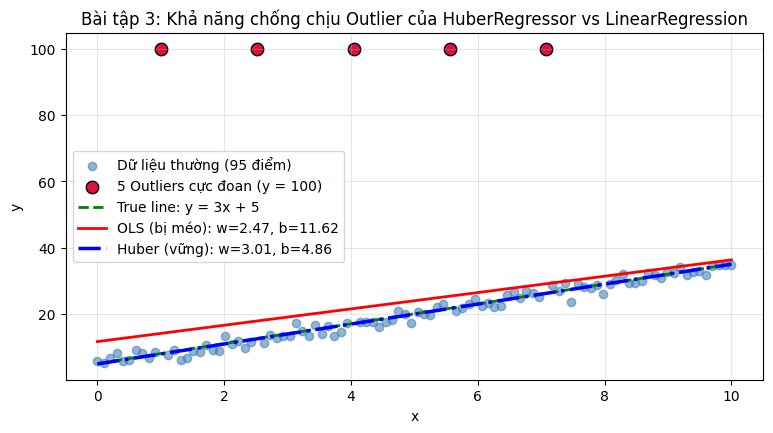

In [17]:
from sklearn.linear_model import HuberRegressor
np.random.seed(42)
N3 = 100
x3 = np.linspace(0, 10, N3)
y3 = 3 * x3 + 5 + np.random.randn(N3) * 1.5

# Thêm 5 outlier mạnh (y = 100)
y3_outlier = y3.copy()
outlier_indices = [10, 25, 40, 55, 70]
y3_outlier[outlier_indices] = 100.0

# 1. Train LinearRegression (OLS - hàm mất mát MSE)
ols3 = LinearRegression()
ols3.fit(x3.reshape(-1, 1), y3_outlier)

# 2. Train HuberRegressor (robust loss)
huber3 = HuberRegressor()
huber3.fit(x3.reshape(-1, 1), y3_outlier)

print(f"Ground Truth:      w = 3.0000,  b = 5.0000")
print(f"Linear Regression: w = {ols3.coef_[0]:.4f},  b = {ols3.intercept_:.4f}")
print(f"HuberRegressor:    w = {huber3.coef_[0]:.4f},  b = {huber3.intercept_:.4f}")

diff_ols = np.sqrt((ols3.coef_[0] - 3)**2 + (ols3.intercept_ - 5)**2)
diff_huber = np.sqrt((huber3.coef_[0] - 3)**2 + (huber3.intercept_ - 5)**2)
print(f"\nĐộ lệch tham số so với nghiệm thật (3, 5):")
print(f"  - Linear Regression lệch: {diff_ols:.4f}")
print(f"  - HuberRegressor lệch:    {diff_huber:.4f}")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(9, 4.5))
normal_idx = [i for i in range(N3) if i not in outlier_indices]
plt.scatter(x3[normal_idx], y3_outlier[normal_idx], alpha=0.6, color='steelblue', label='Dữ liệu thường (95 điểm)')
plt.scatter(x3[outlier_indices], y3_outlier[outlier_indices], color='crimson', s=80, edgecolors='black', label='5 Outliers cực đoan (y = 100)')

x3_plot = np.linspace(0, 10, 200).reshape(-1, 1)
plt.plot(x3_plot, 3 * x3_plot + 5, 'g--', lw=2, label='True line: y = 3x + 5')
plt.plot(x3_plot, ols3.predict(x3_plot), 'r-', lw=2, label=f'OLS (bị méo): w={ols3.coef_[0]:.2f}, b={ols3.intercept_:.2f}')
plt.plot(x3_plot, huber3.predict(x3_plot), 'b-.', lw=2.5, label=f'Huber (vững): w={huber3.coef_[0]:.2f}, b={huber3.intercept_:.2f}')

plt.xlabel('x'); plt.ylabel('y')
plt.title('Bài tập 3: Khả năng chống chịu Outlier của HuberRegressor vs LinearRegression')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Nhận xét Bài 3:**
- **Mô hình HuberRegressor sát với true (3, 5) hơn rất nhiều!**
- **Giải thích nguyên nhân:**
  1. Hàm mất mát **MSE** phạt theo bình phương sai số $e^2 = (y - \hat{y})^2$. Khi có điểm outlier ở $y = 100$, sai số $e \approx 80-90$ tạo ra mức phạt $e^2 \approx 6400-8100$. Đạo hàm $\frac{\partial L}{\partial w} = 2 e x$ cực lớn này kéo lệch hẳn đường hồi quy về phía 5 điểm ngoại lai.
  2. Hàm **Huber Loss** hoạt động linh hoạt: khi sai số nhỏ $|e| \le \delta$, nó phạt bậc hai mượt mà như MSE; nhưng khi $|e| > \delta$ (vùng ngoại lai), nó chuyển sang phạt **tuyến tính** $\delta (|e| - \frac{1}{2}\delta)$. Khi đó đạo hàm theo sai số bị chặn cố định ở mức $\pm \delta$, không bị bùng nổ, triệt tiêu ảnh hưởng thống trị của outlier.

---
### Lời giải Bài 4: Ridge vs Lasso khi có feature thừa

Số feature thật sự có ý nghĩa: 5 / 20
1. Linear Regression: 20/20 coef khác 0
2. Ridge (alpha=1.0): 20/20 coef khác 0
3. Lasso (alpha=0.1): 6/20 coef khác 0

Chỉ số các đặc trưng Lasso chọn (coef > 1e-6): [0 1 2 3 4 8]
Chỉ số 5 đặc trưng thật ban đầu:              [0, 1, 2, 3, 4]


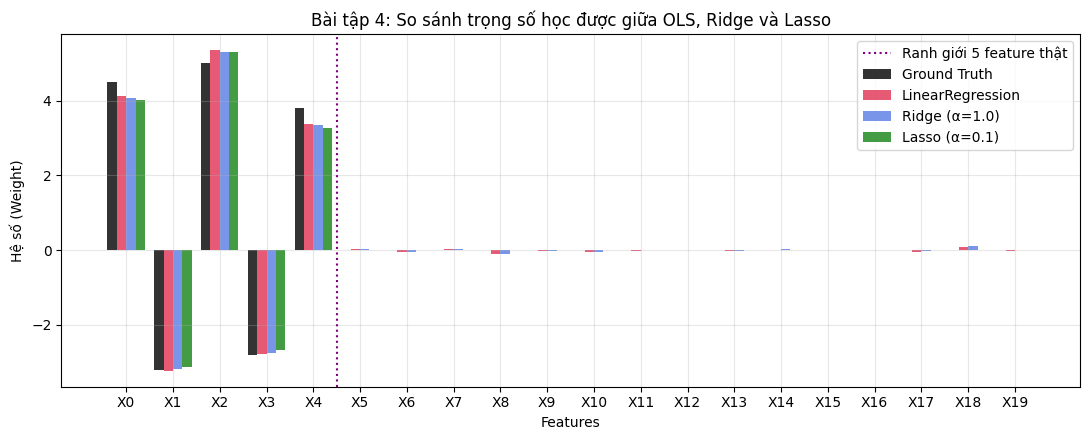

In [14]:
np.random.seed(42)
N4, D4 = 100, 20
# Sinh dữ liệu 100 mẫu, 20 đặc trưng
X4 = np.random.randn(N4, D4)

# Chỉ 5 đặc trưng đầu tiên thật sự liên quan, 15 đặc trưng sau là nhiễu
true_coef4 = np.zeros(D4)
true_coef4[:5] = [4.5, -3.2, 5.0, -2.8, 3.8]
y4 = X4 @ true_coef4 + np.random.randn(N4) * 0.5

# Chuẩn hóa đặc trưng
scaler4 = StandardScaler()
X4_s = scaler4.fit_transform(X4)

# 1. Huấn luyện 3 mô hình
lr4 = LinearRegression().fit(X4_s, y4)
ridge4 = Ridge(alpha=1.0).fit(X4_s, y4)
lasso4 = Lasso(alpha=0.1).fit(X4_s, y4)

# 2. Đếm số hệ số khác 0 (ngưỡng 1e-6)
nz_lr4 = np.sum(np.abs(lr4.coef_) > 1e-6)
nz_ridge4 = np.sum(np.abs(ridge4.coef_) > 1e-6)
nz_lasso4 = np.sum(np.abs(lasso4.coef_) > 1e-6)

print(f"Số feature thật sự có ý nghĩa: 5 / 20")
print(f"1. Linear Regression: {nz_lr4}/20 coef khác 0")
print(f"2. Ridge (alpha=1.0): {nz_ridge4}/20 coef khác 0")
print(f"3. Lasso (alpha=0.1): {nz_lasso4}/20 coef khác 0")

# 3. Kiểm tra Lasso có phát hiện 5 feature thật không
selected_features = np.where(np.abs(lasso4.coef_) > 1e-6)[0]
print(f"\nChỉ số các đặc trưng Lasso chọn (coef > 1e-6): {selected_features}")
print(f"Chỉ số 5 đặc trưng thật ban đầu:              [0, 1, 2, 3, 4]")
if np.array_equal(selected_features, np.arange(5)):
    print("=> Lasso đã phát hiện CHÍNH XÁC HOÀN TOÀN 5 feature thật và triệt tiêu 15 feature thừa về 0!")

# Vẽ biểu đồ so sánh trọng số của 3 mô hình
plt.figure(figsize=(11, 4.5))
idx = np.arange(D4)
w_bar = 0.2
plt.bar(idx - 1.5*w_bar, true_coef4, w_bar, label='Ground Truth', color='black', alpha=0.8)
plt.bar(idx - 0.5*w_bar, lr4.coef_, w_bar, label='LinearRegression', color='crimson', alpha=0.7)
plt.bar(idx + 0.5*w_bar, ridge4.coef_, w_bar, label='Ridge (α=1.0)', color='royalblue', alpha=0.7)
plt.bar(idx + 1.5*w_bar, lasso4.coef_, w_bar, label='Lasso (α=0.1)', color='forestgreen', alpha=0.85)
plt.axvline(4.5, color='purple', linestyle=':', label='Ranh giới 5 feature thật')
plt.xticks(idx, [f'X{i}' for i in range(D4)])
plt.xlabel('Features')
plt.ylabel('Hệ số (Weight)')
plt.title('Bài tập 4: So sánh trọng số học được giữa OLS, Ridge và Lasso')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### Lời giải Bài 5: Polynomial degree và overfit

Đáy của đường test RMSE đạt tại: degree = 3
  - Train RMSE tại degree 3: 0.2126
  - Test RMSE tại degree 3 : 0.2276


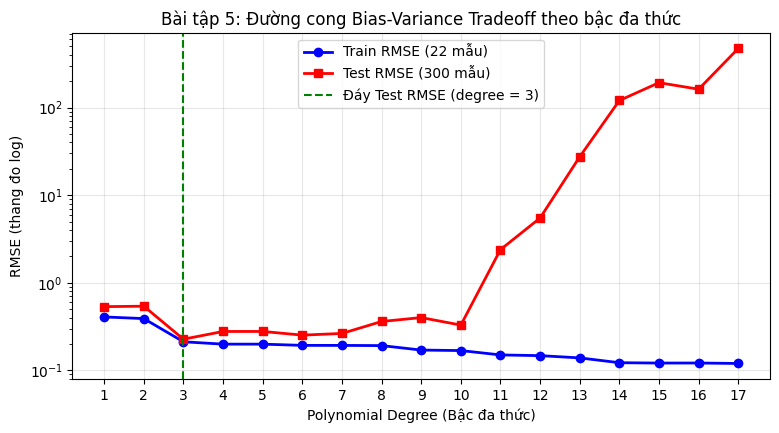

In [15]:
# Sử dụng lại tập dữ liệu sin(x) từ phần Thực hành cuối
np.random.seed(0)
x_train_5 = np.sort(np.random.uniform(0, 2*np.pi, 22))
y_train_5 = np.sin(x_train_5) + np.random.randn(22) * 0.20

x_test_5 = np.sort(np.random.uniform(0, 2*np.pi, 300))
y_test_5 = np.sin(x_test_5) + np.random.randn(300) * 0.20

degrees = range(1, 18)
train_rmses = []
test_rmses = []

for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    pipe.fit(x_train_5.reshape(-1, 1), y_train_5)
    
    pred_tr = pipe.predict(x_train_5.reshape(-1, 1))
    pred_te = pipe.predict(x_test_5.reshape(-1, 1))
    
    train_rmses.append(np.sqrt(mean_squared_error(y_train_5, pred_tr)))
    test_rmses.append(np.sqrt(mean_squared_error(y_test_5, pred_te)))

best_d_idx = np.argmin(test_rmses)
best_d = list(degrees)[best_d_idx]
print(f"Đáy của đường test RMSE đạt tại: degree = {best_d}")
print(f"  - Train RMSE tại degree {best_d}: {train_rmses[best_d_idx]:.4f}")
print(f"  - Test RMSE tại degree {best_d} : {test_rmses[best_d_idx]:.4f}")

# Vẽ đồ thị so sánh RMSE theo degree (thang log)
plt.figure(figsize=(9, 4.5))
plt.plot(degrees, train_rmses, 'b-o', lw=2, label='Train RMSE (22 mẫu)')
plt.plot(degrees, test_rmses, 'r-s', lw=2, label='Test RMSE (300 mẫu)')
plt.axvline(best_d, color='green', linestyle='--', label=f'Đáy Test RMSE (degree = {best_d})')
plt.yscale('log')
plt.xticks(degrees)
plt.xlabel('Polynomial Degree (Bậc đa thức)')
plt.ylabel('RMSE (thang đo log)')
plt.title('Bài tập 5: Đường cong Bias-Variance Tradeoff theo bậc đa thức')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
### Trả lời câu hỏi thêm Bài 5: Tăng tập train lên 500 điểm

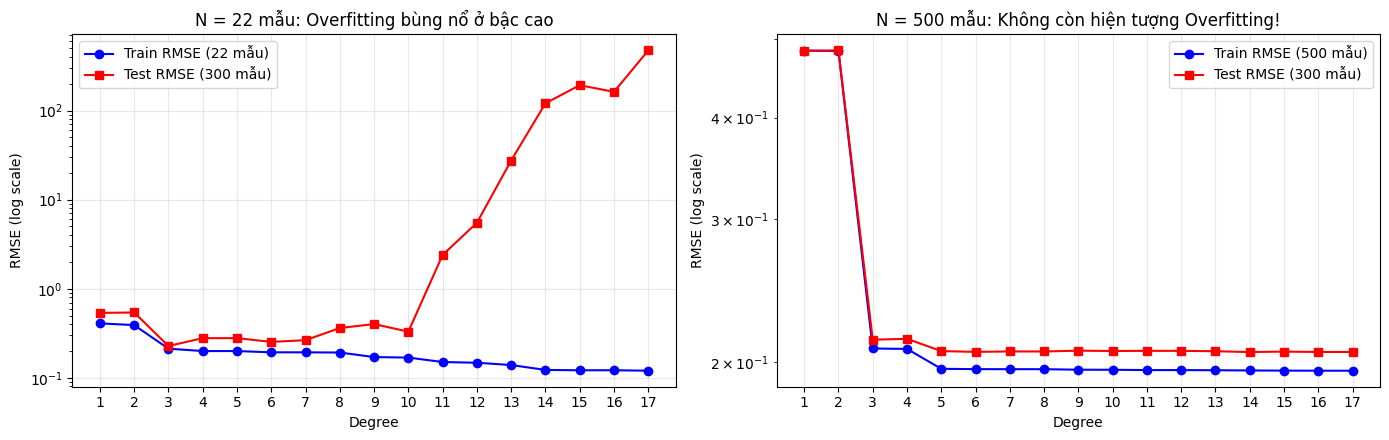

Khi N = 500 mẫu:
  - Degree 3:  Test RMSE = 0.2130
  - Degree 17: Test RMSE = 0.2057


In [16]:
# Sinh dữ liệu train lớn: N = 500 điểm
np.random.seed(0)
x_train_500 = np.sort(np.random.uniform(0, 2*np.pi, 500))
y_train_500 = np.sin(x_train_500) + np.random.randn(500) * 0.20

train_rmses_500 = []
test_rmses_500 = []

for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    pipe.fit(x_train_500.reshape(-1, 1), y_train_500)
    
    pred_tr = pipe.predict(x_train_500.reshape(-1, 1))
    pred_te = pipe.predict(x_test_5.reshape(-1, 1))
    
    train_rmses_500.append(np.sqrt(mean_squared_error(y_train_500, pred_tr)))
    test_rmses_500.append(np.sqrt(mean_squared_error(y_test_5, pred_te)))

# Vẽ so sánh 2 trường hợp: 22 mẫu vs 500 mẫu
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(degrees, train_rmses, 'b-o', label='Train RMSE (22 mẫu)')
ax1.plot(degrees, test_rmses, 'r-s', label='Test RMSE (300 mẫu)')
ax1.set_yscale('log'); ax1.set_xticks(degrees)
ax1.set_xlabel('Degree'); ax1.set_ylabel('RMSE (log scale)')
ax1.set_title('N = 22 mẫu: Overfitting bùng nổ ở bậc cao')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(degrees, train_rmses_500, 'b-o', label='Train RMSE (500 mẫu)')
ax2.plot(degrees, test_rmses_500, 'r-s', label='Test RMSE (300 mẫu)')
ax2.set_yscale('log'); ax2.set_xticks(degrees)
ax2.set_xlabel('Degree'); ax2.set_ylabel('RMSE (log scale)')
ax2.set_title('N = 500 mẫu: Không còn hiện tượng Overfitting!')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Khi N = 500 mẫu:")
print(f"  - Degree 3:  Test RMSE = {test_rmses_500[2]:.4f}")
print(f"  - Degree 17: Test RMSE = {test_rmses_500[-1]:.4f}")